<a href="https://colab.research.google.com/github/IbrahimBajwa313/DataSciencePrjects/blob/master/Lab5_Polynomial_Regression_and_Model_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

In [3]:
# Load dataset as pandas DataFrame
california = fetch_california_housing(as_frame=True)
df = california.frame


In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


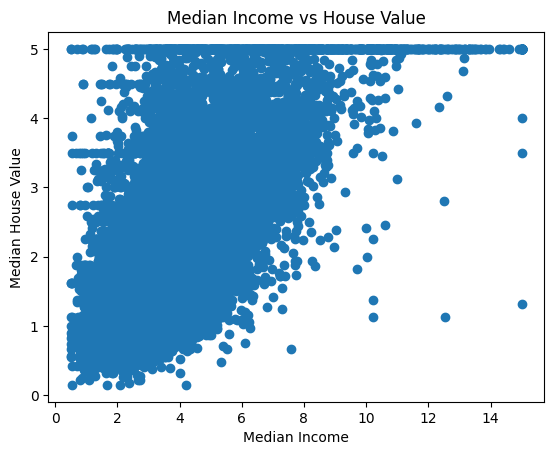

In [7]:
plt.scatter(df['MedInc'], df['MedHouseVal'])
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Median Income vs House Value')
plt.show()

In [8]:
X = df[['MedInc']].values
y = df['MedHouseVal'].values
# Split into training and testing sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Task 3: Implement Linear Regression


In [9]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [10]:
# 2. Predict house values
y_pred = model.predict(X_test)


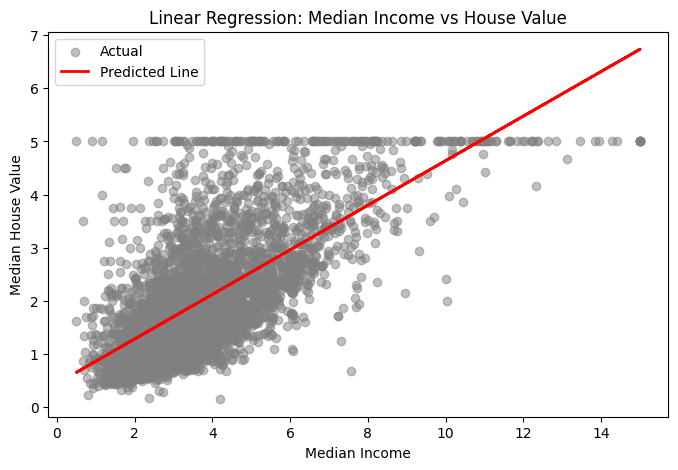

In [11]:
# 3. Visualize regression line
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, color='gray', alpha=0.5, label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted Line')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Linear Regression: Median Income vs House Value')
plt.legend()
plt.show()

In [12]:
# 4. Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== Model Evaluation ===")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

=== Model Evaluation ===
Mean Squared Error (MSE): 0.7091
Root Mean Squared Error (RMSE): 0.8421
R² Score: 0.4589


# Task 4: Implement Polynomial Regression

In [13]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [14]:
degrees = [2, 3, 4, 5]
train_r2_scores = []
test_r2_scores = []
train_mse_scores = []
test_mse_scores = []

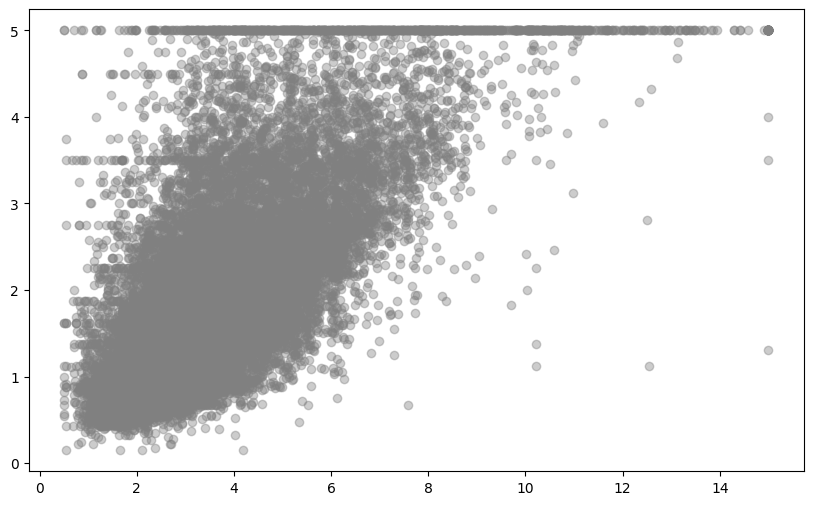

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='gray', alpha=0.4, label='Actual Data')


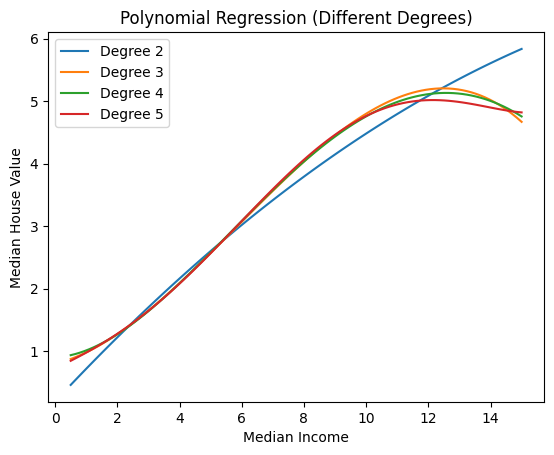

In [16]:
train_mse_scores = []
test_mse_scores = []
train_r2_scores = []
test_r2_scores = []

for degree in degrees:
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_poly_train = poly.fit_transform(X_train)
    X_poly_test = poly.transform(X_test)

    # Fit Linear Regression on polynomial features
    poly_model = LinearRegression()
    poly_model.fit(X_poly_train, y_train)

    # Predict on training and test data
    y_train_pred = poly_model.predict(X_poly_train)
    y_test_pred = poly_model.predict(X_poly_test)

    # Compute metrics
    train_mse_scores.append(mean_squared_error(y_train, y_train_pred))
    test_mse_scores.append(mean_squared_error(y_test, y_test_pred))
    train_r2_scores.append(r2_score(y_train, y_train_pred))
    test_r2_scores.append(r2_score(y_test, y_test_pred))

    # Plot polynomial curve
    X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    X_plot_poly = poly.transform(X_plot)
    y_plot = poly_model.predict(X_plot_poly)
    plt.plot(X_plot, y_plot, label=f'Degree {degree}')

plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Polynomial Regression (Different Degrees)')
plt.legend()
plt.show()


# Task 5: Analyze Overfitting and Underfitting

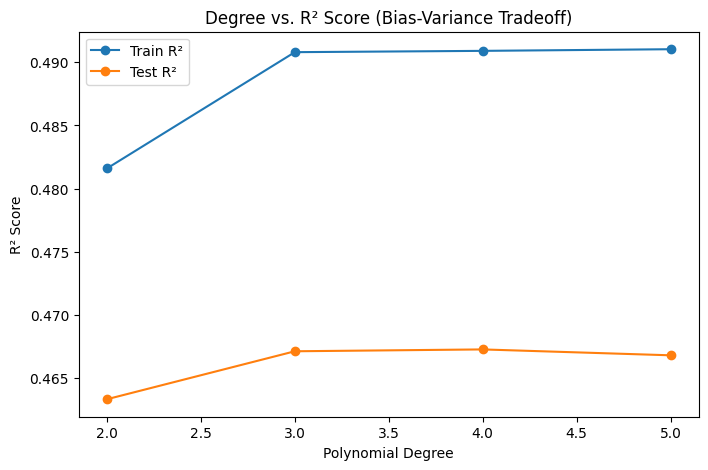

In [17]:
plt.figure(figsize=(8,5))
plt.plot(degrees, train_r2_scores, marker='o', label='Train R²')
plt.plot(degrees, test_r2_scores, marker='o', label='Test R²')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Degree vs. R² Score (Bias-Variance Tradeoff)')
plt.legend()
plt.show()


In [18]:
print("🔍 Analysis:")
print("As degree increases, training R² generally increases, but test R² may start to drop,")
print("indicating overfitting at higher degrees. The best degree is where both scores are high and close — usually degree 2 or 3.")


🔍 Analysis:
As degree increases, training R² generally increases, but test R² may start to drop,
indicating overfitting at higher degrees. The best degree is where both scores are high and close — usually degree 2 or 3.


# Task 6: Effect of Feature Scaling

In [19]:

scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)

for degree in [2, 3]:
    print(f"\n=== Polynomial Regression (Degree {degree}) - Without Scaling ===")
    poly = PolynomialFeatures(degree=degree)
    X_poly_train = poly.fit_transform(X_train)
    X_poly_test = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_poly_train, y_train)
    y_pred = model.predict(X_poly_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"MSE: {mse:.4f}, R²: {r2:.4f}")

    print(f"=== Polynomial Regression (Degree {degree}) - With Scaling ===")
    X_poly_scaled_train = poly.fit_transform(X_scaled_train)
    X_poly_scaled_test = poly.transform(X_scaled_test)

    model_scaled = LinearRegression()
    model_scaled.fit(X_poly_scaled_train, y_train)
    y_pred_scaled = model_scaled.predict(X_poly_scaled_test)

    mse_scaled = mean_squared_error(y_test, y_pred_scaled)
    r2_scaled = r2_score(y_test, y_pred_scaled)
    print(f"MSE (Scaled): {mse_scaled:.4f}, R² (Scaled): {r2_scaled:.4f}")

print("\n📈 Scaling helps stabilize polynomial regression by reducing large value ranges and improving numerical performance.")



=== Polynomial Regression (Degree 2) - Without Scaling ===
MSE: 0.7033, R²: 0.4633
=== Polynomial Regression (Degree 2) - With Scaling ===
MSE (Scaled): 0.7033, R² (Scaled): 0.4633

=== Polynomial Regression (Degree 3) - Without Scaling ===
MSE: 0.6983, R²: 0.4671
=== Polynomial Regression (Degree 3) - With Scaling ===
MSE (Scaled): 0.6983, R² (Scaled): 0.4671

📈 Scaling helps stabilize polynomial regression by reducing large value ranges and improving numerical performance.


Task 7: Ridge Regularization (Manual Tuning)

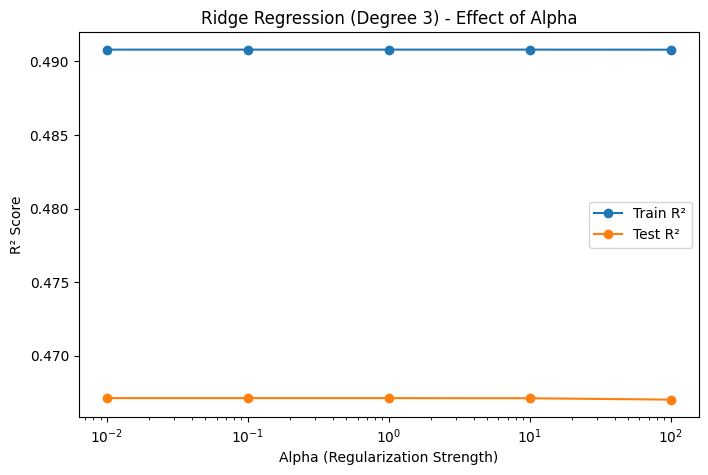

In [20]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

alphas = [0.01, 0.1, 1, 10, 100]
degree = 3

train_r2_scores = []
test_r2_scores = []

poly = PolynomialFeatures(degree=degree)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_poly_train, y_train)

    y_train_pred = ridge.predict(X_poly_train)
    y_test_pred = ridge.predict(X_poly_test)

    train_r2_scores.append(r2_score(y_train, y_train_pred))
    test_r2_scores.append(r2_score(y_test, y_test_pred))

plt.figure(figsize=(8,5))
plt.plot(alphas, train_r2_scores, marker='o', label='Train R²')
plt.plot(alphas, test_r2_scores, marker='o', label='Test R²')
plt.xscale('log')  # use log scale for alpha
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('R² Score')
plt.title(f'Ridge Regression (Degree {degree}) - Effect of Alpha')
plt.legend()
plt.show()


Task 8: Compare Manual Tuning with Grid Search

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

param_grid = {
    'poly__degree': [2, 3, 4, 5],
    'ridge__alpha': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation R²:", grid.best_score_)


Best Parameters: {'poly__degree': 5, 'ridge__alpha': 0.01}
Best Cross-Validation R²: 0.49069014137147454


Task 9: Visualization & Discussion

In [26]:
# Get the best polynomial and ridge models from the grid search
best_poly_ridge_model = grid.best_estimator_

# Predict using the linear regression model
y_pred_linear = model.predict(X_test)

# Predict using the best polynomial and ridge model from grid search
y_pred_poly_ridge = best_poly_ridge_model.predict(X_test)

Now let's rename the predicted values for polynomial and ridge from grid search to `y_pred_poly_ridge` since the best model from grid search combines both polynomial features and ridge regularization.

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_linear, alpha=0.5, label='Linear')
plt.scatter(y_test, y_pred_poly_ridge, alpha=0.5, label='Polynomial & Ridge (Best from Grid Search)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.title('Actual vs Predicted House Values')
plt.show()